In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import math

In [4]:
df = pd.read_csv("donnees_mpox_RDC_3000.csv")
df

,ID,Semaine,Province,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Saison,Population_Risque,Taux_Positivite_pct
0,OBS_00001,1,Mongala,206,24.4,0.480,64,39,31.8,150,22,1,4,29,Pluie,3478,19.33
1,OBS_00002,2,Kinshasa,56,23.7,0.474,74,107,24.9,300,5,1,6,42,Seche,3713,14.00
2,OBS_00003,3,Kinshasa,59,25.2,0.333,62,140,53.9,310,16,0,8,20,Seche,4833,6.45
3,OBS_00004,4,Mai-Ndombe,396,24.1,0.354,68,97,25.9,210,4,0,10,82,Pluie,3777,39.05
4,OBS_00005,5,Kasaï,127,19.8,0.303,61,86,30.3,260,24,1,6,24,Pluie,9396,9.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,OBS_02996,2996,Kongo Central,271,31.6,0.534,88,57,22.4,220,33,1,7,125,Pluie,3166,56.82
2996,OBS_02997,2997,Sud-Ubangi,88,24.6,0.262,95,47,34.1,370,7,1,6,70,Seche,6099,18.92
2997,OBS_02998,2998,Bas-Uele,268,25.6,0.720,58,18,41.9,190,23,0,2,36,Pluie,5475,18.95
2998,OBS_02999,2999,Haut-Uele,211,24.9,0.196,77,28,10.6,370,2,0,2,160,Pluie,4813,43.24


# A. ANALYSE EXPLORATOIRE APPROFONDUE 

# 1. VERIFICATION DE VALEURS MANQUANTES  

In [5]:
count = df.isnull().sum()
print(count)

ID                          0
Semaine                     0
Province                    0
Pluviometrie_mm             0
Temperature_C               0
NDVI                        0
Humidite_pct                0
Densite_Population          0
Couverture_Vaccinale_pct    0
Tests_Realises              0
Distance_Centre_Sante_km    0
Reservoirs_Animaux          0
Mobilite_Humaine            0
Cas_Confirmes               0
Saison                      0
Population_Risque           0
Taux_Positivite_pct         0
dtype: int64


In [6]:
df.columns = df.columns.str.strip()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        3000 non-null   object 
 1   Semaine                   3000 non-null   int64  
 2   Province                  3000 non-null   object 
 3   Pluviometrie_mm           3000 non-null   int64  
 4   Temperature_C             3000 non-null   float64
 5   NDVI                      3000 non-null   float64
 6   Humidite_pct              3000 non-null   int64  
 7   Densite_Population        3000 non-null   int64  
 8   Couverture_Vaccinale_pct  3000 non-null   float64
 9   Tests_Realises            3000 non-null   int64  
 10  Distance_Centre_Sante_km  3000 non-null   int64  
 11  Reservoirs_Animaux        3000 non-null   int64  
 12  Mobilite_Humaine          3000 non-null   int64  
 13  Cas_Confirmes             3000 non-null   int64  
 14  Saison  

# 2. STATISTIQUES DESCRIPTIVES

In [8]:
df.drop(columns=['ID','Semaine', 'Province']).describe()

,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Population_Risque,Taux_Positivite_pct
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000
mean,157.779667,24.980367,0.451182,71.571667,119.100333,31.843967,286.143333,15.558333,0.40000,5.018000,79.603333,5471.297667,27.041943
std,101.958774,3.832510,0.157799,11.625285,95.218460,14.079517,88.256194,15.139386,0.48998,1.954213,70.119799,2636.188129,20.156959
min,2.000000,18.000000,0.103000,40.000000,5.000000,5.600000,90.000000,1.000000,0.00000,1.000000,0.000000,1001.000000,0.000000
25%,77.000000,22.300000,0.331000,64.000000,48.000000,20.800000,220.000000,5.000000,0.00000,4.000000,29.000000,3127.000000,11.430000
50%,136.000000,24.900000,0.452000,71.500000,94.000000,30.400000,280.000000,11.000000,0.00000,5.000000,57.000000,5514.500000,21.455000
75%,221.000000,27.600000,0.576000,80.000000,163.000000,41.525000,340.000000,22.000000,1.00000,6.000000,109.000000,7819.250000,38.070000
max,400.000000,34.000000,0.795000,95.000000,500.000000,77.800000,800.000000,142.000000,1.00000,10.000000,479.000000,9997.000000,95.000000


# TRANSFORMATION DES VARIABLES TEXTUELLES EN NUMERIQUES 

In [9]:
df['Saison_num'] = df['Saison'].map({'Seche': 0, 'Pluie': 1})

# 3. MATRICE DE CORRELATION 

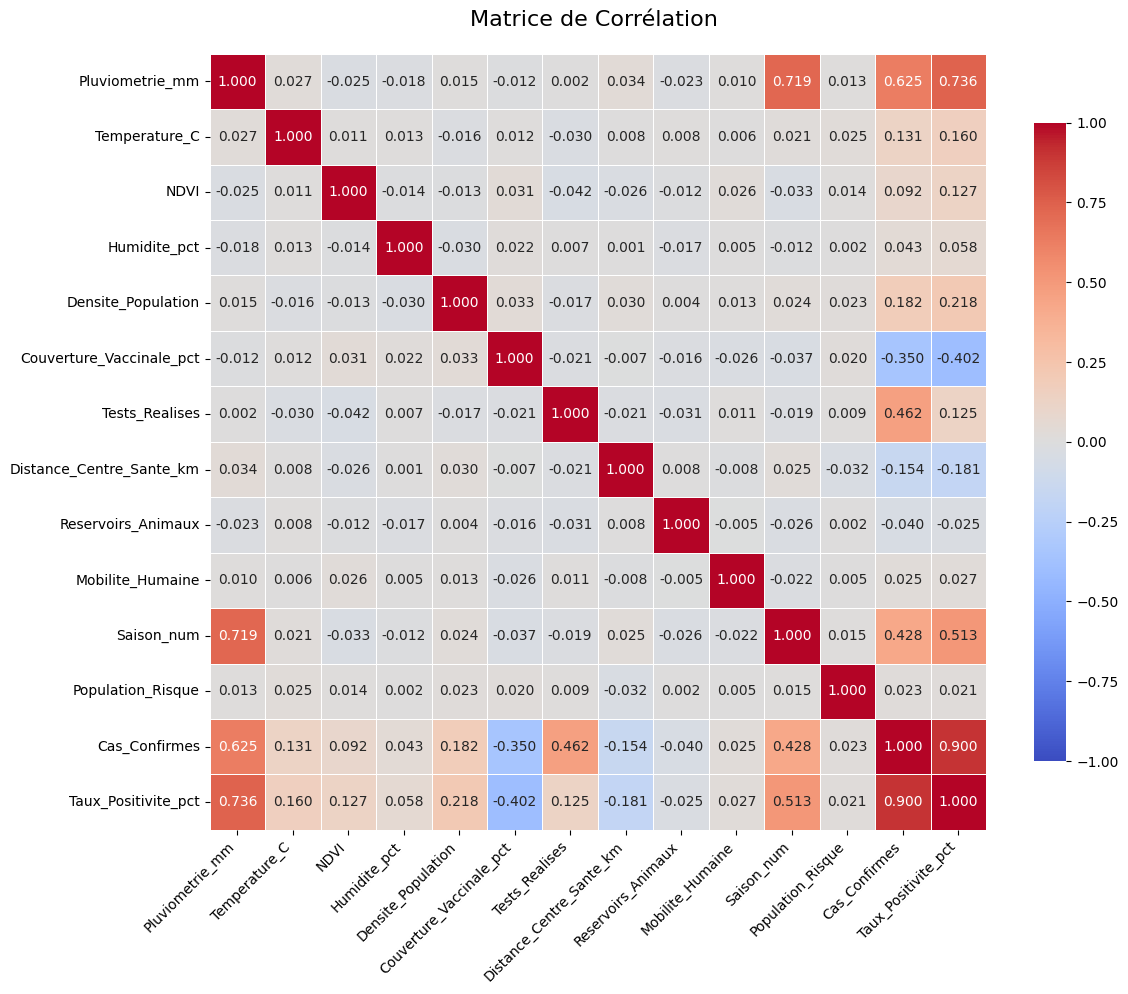

In [10]:
corr_matrix = df[['Pluviometrie_mm', 'Temperature_C', 'NDVI', 'Humidite_pct', 'Densite_Population', 'Couverture_Vaccinale_pct', 'Tests_Realises', 
    'Distance_Centre_Sante_km', 'Reservoirs_Animaux', 'Mobilite_Humaine', 'Saison_num','Population_Risque', 'Cas_Confirmes', 'Taux_Positivite_pct']].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={"shrink": .8} )

plt.title("Matrice de Corrélation ", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right", fontsize=10) 
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

# INTERPRETATION:

Les variables suivantes ont une relation linaire avec les Cas confirmés de Mpox:
- Pluviometrie_mm (r=0.625): il y a une très forte corrélation positive, plus il pleut , plus il y a les cas confirmés de Mpox;
- Tests_Realises (r=0.462): il y a une corrélation positive modérée, plus on teste , plus on trouve de cas confirmés;
- Saison_num (r=0.428): le passage de la saison sèche à la saison de pluie est associé au nombre de cas confirmés de Mpox;
 

# 4. DISTRIBUTION DES VARIABLES (Histogrammes + KDE) 

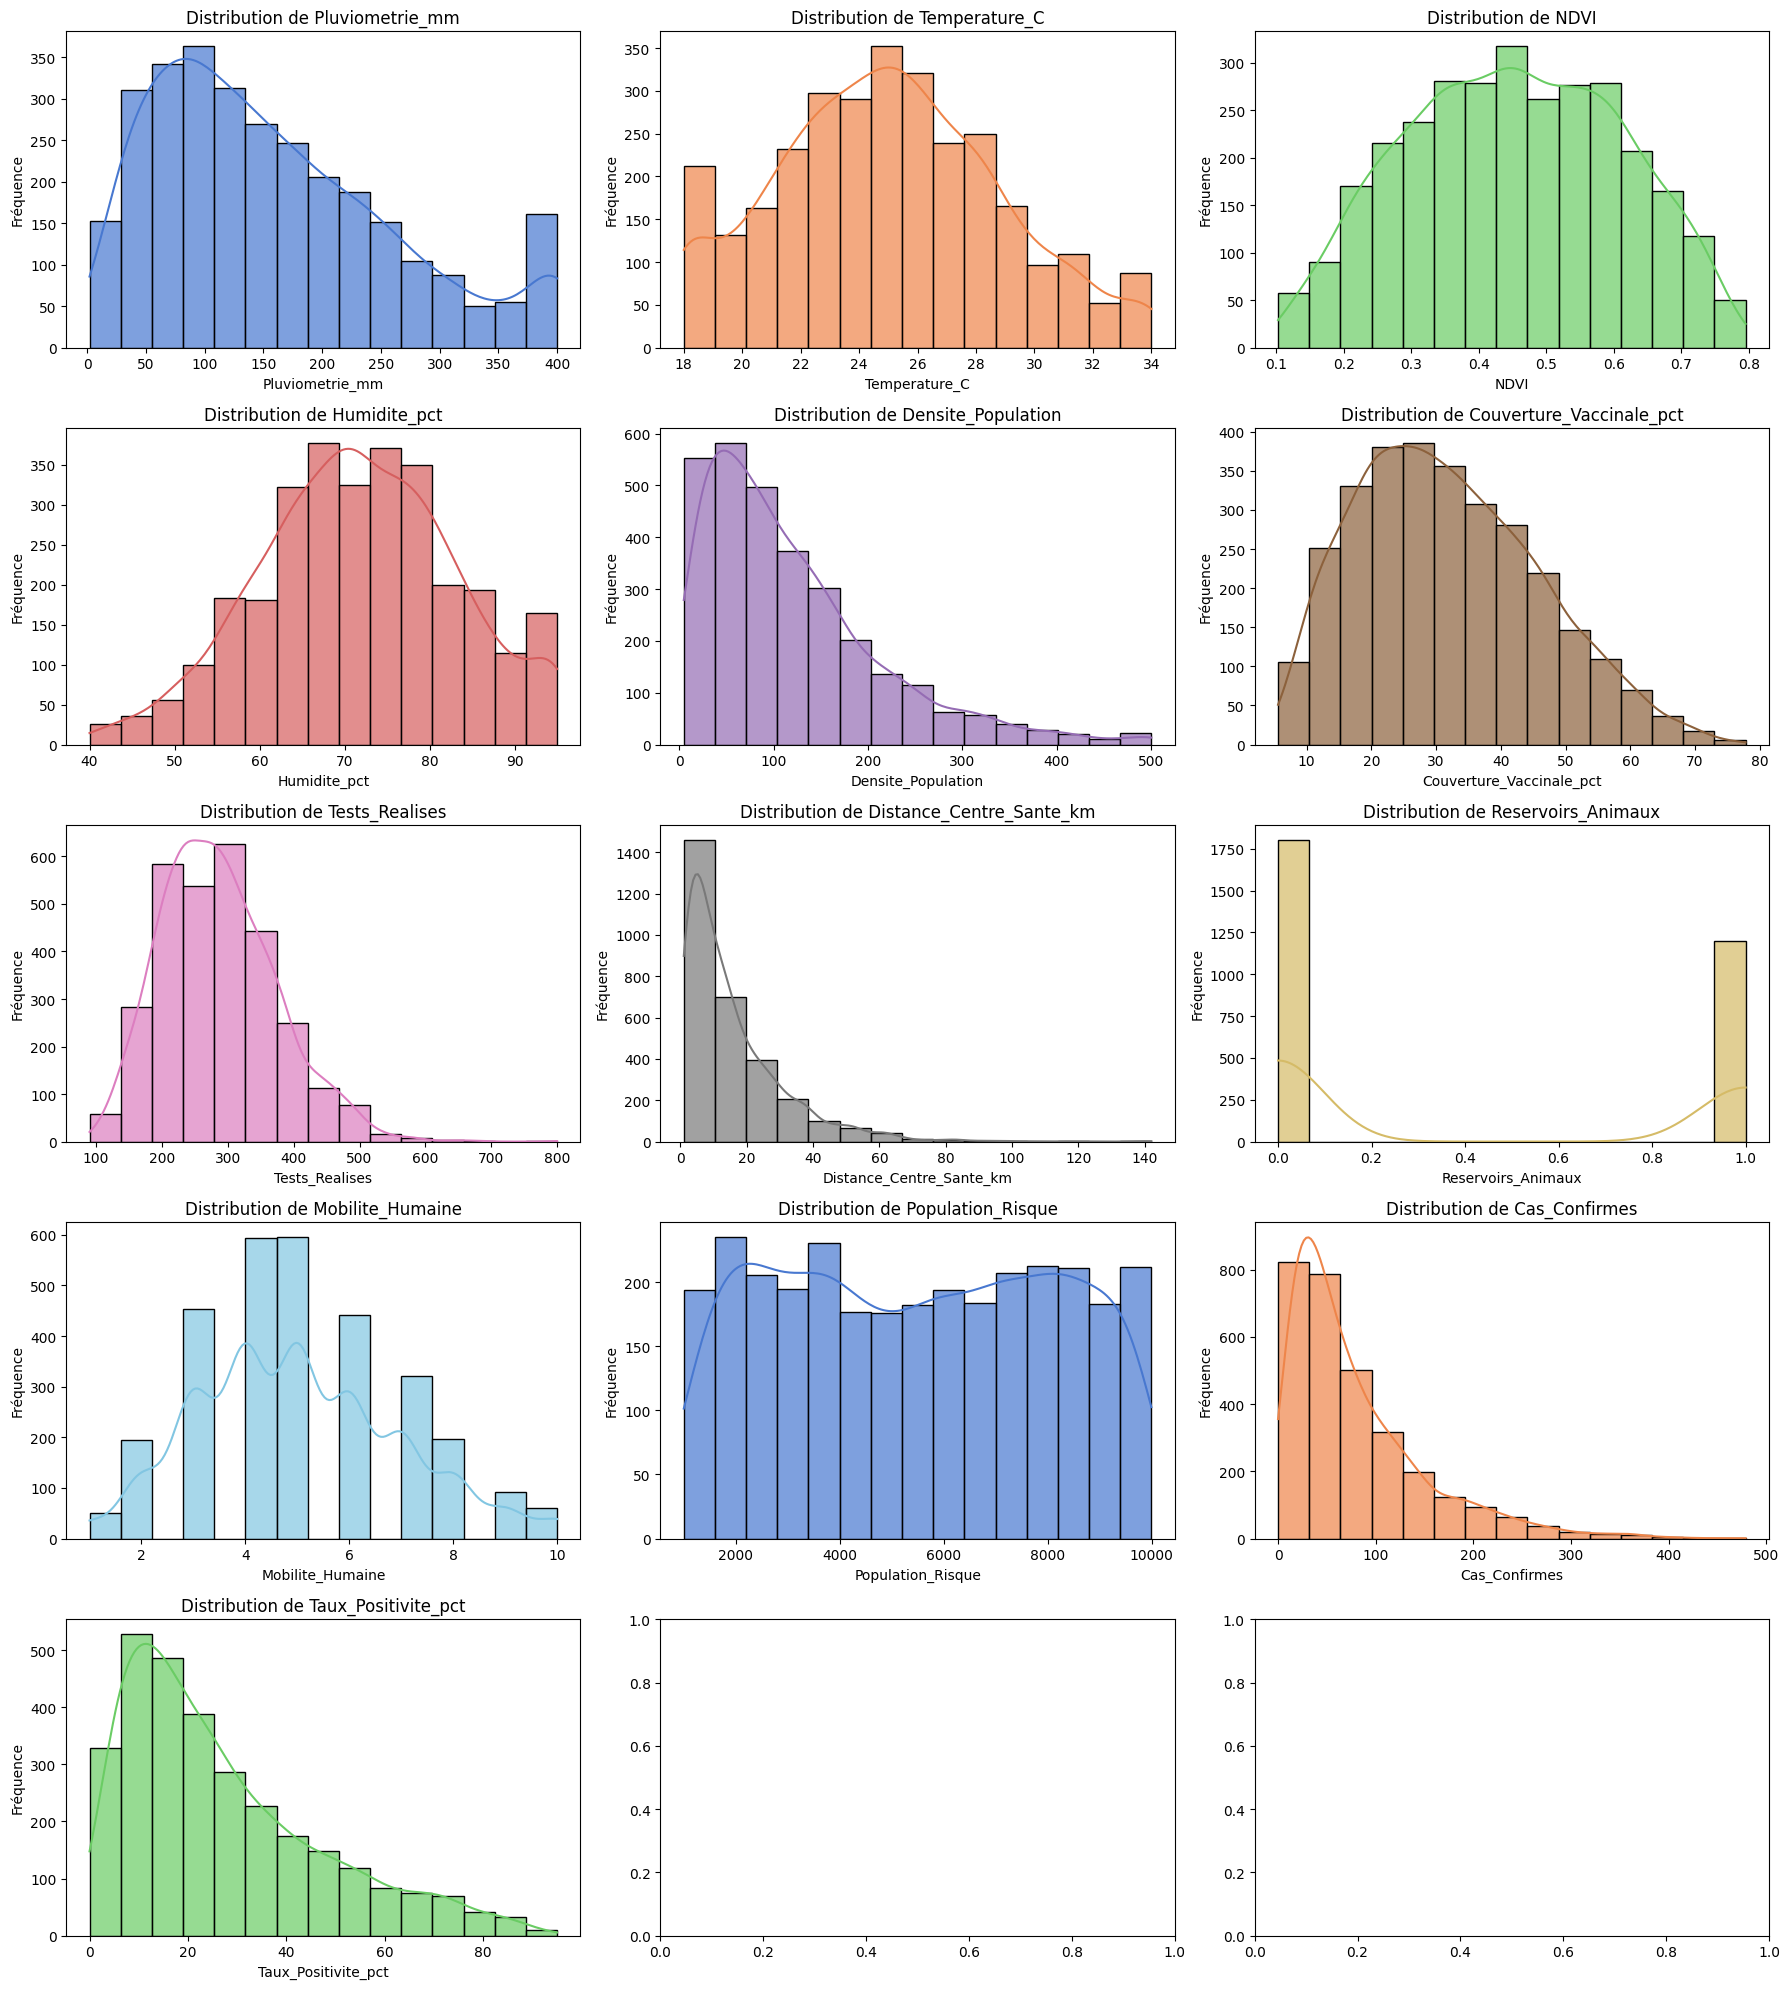

In [11]:
fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

variables = ['Pluviometrie_mm', 'Temperature_C', 'NDVI', 'Humidite_pct', 'Densite_Population', 'Couverture_Vaccinale_pct', 'Tests_Realises', 
    'Distance_Centre_Sante_km', 'Reservoirs_Animaux', 'Mobilite_Humaine', 'Population_Risque', 'Cas_Confirmes', 'Taux_Positivite_pct']
# couleurs = ['steelblue', 'coral', 'forestgreen', 'goldenrod', 'purple', 'teal']
couleurs = sns.color_palette("muted", len(variables))

for i, (var, color) in enumerate(zip(variables, couleurs)):
    sns.histplot(df[var], kde=True, ax=axes[i], color=color, bins=15, alpha=0.7)
    axes[i].set_title(f'Distribution de {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

# DETECTION DES OUTLIERS

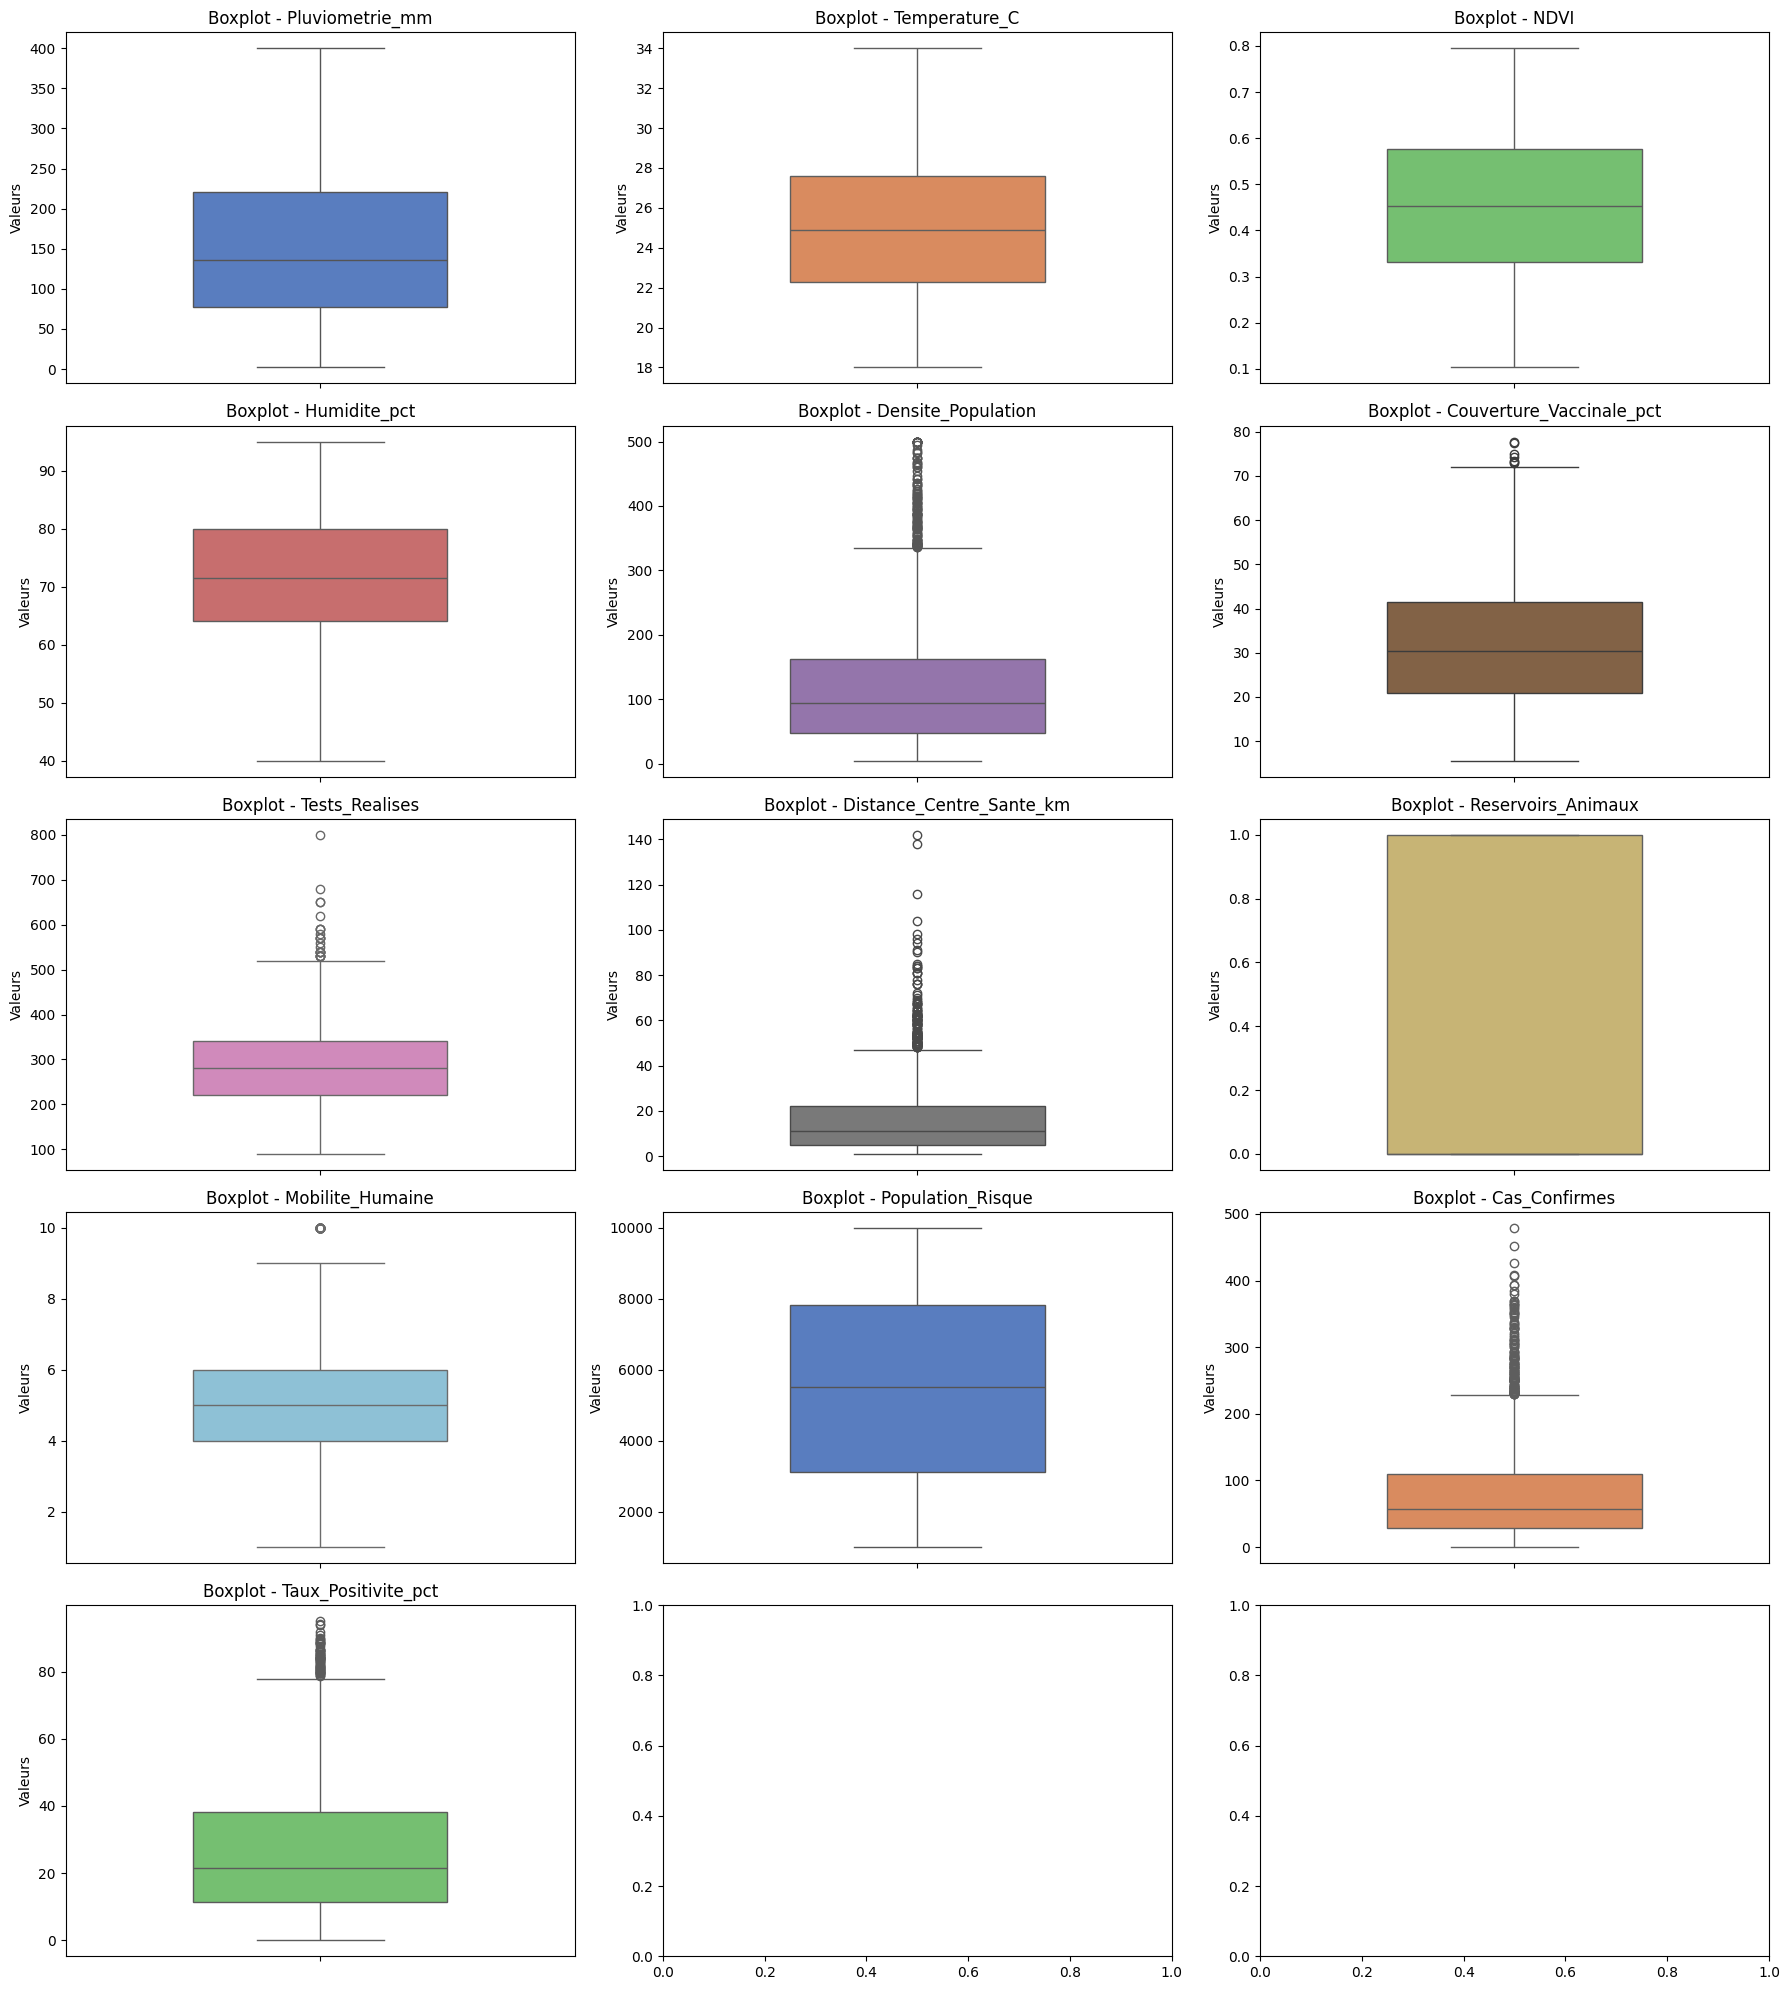

In [12]:
fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

for i, (var, color) in enumerate(zip(variables, couleurs)):
    sns.boxplot(y=df[var], ax=axes[i], color=color, width=0.5)
    axes[i].set_title(f'Boxplot - {var}')
    axes[i].set_ylabel('Valeurs')

plt.tight_layout()
plt.show()

#  LA NORMALISATION DES DONNEES 

In [13]:
df_scaler = df.copy()

cols_a_normaliser = [col for col in df.columns if col not in ['ID', 'Semaine', 'Province','Cas_Confirmes', 'Saison_num', 'Saison']]

minmax = MinMaxScaler()
df_scaler[cols_a_normaliser] = minmax.fit_transform(df[cols_a_normaliser])

df_scaler

,ID,Semaine,Province,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Saison,Population_Risque,Taux_Positivite_pct,Saison_num
0,OBS_00001,1,Mongala,0.512563,0.40000,0.544798,0.436364,0.068687,0.362881,0.084507,0.148936,1.0,0.333333,29,Pluie,0.275345,0.203474,1
1,OBS_00002,2,Kinshasa,0.135678,0.35625,0.536127,0.618182,0.206061,0.267313,0.295775,0.028369,1.0,0.555556,42,Seche,0.301467,0.147368,0
2,OBS_00003,3,Kinshasa,0.143216,0.45000,0.332370,0.400000,0.272727,0.668975,0.309859,0.106383,0.0,0.777778,20,Seche,0.425967,0.067895,0
3,OBS_00004,4,Mai-Ndombe,0.989950,0.38125,0.362717,0.509091,0.185859,0.281163,0.169014,0.021277,0.0,1.000000,82,Pluie,0.308582,0.411053,1
4,OBS_00005,5,Kasaï,0.314070,0.11250,0.289017,0.381818,0.163636,0.342105,0.239437,0.163121,1.0,0.555556,24,Pluie,0.933193,0.097158,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,OBS_02996,2996,Kongo Central,0.675879,0.85000,0.622832,0.872727,0.105051,0.232687,0.183099,0.226950,1.0,0.666667,125,Pluie,0.240663,0.598105,1
2996,OBS_02997,2997,Sud-Ubangi,0.216080,0.41250,0.229769,1.000000,0.084848,0.394737,0.394366,0.042553,1.0,0.555556,70,Seche,0.566696,0.199158,0
2997,OBS_02998,2998,Bas-Uele,0.668342,0.47500,0.891618,0.327273,0.026263,0.502770,0.140845,0.156028,0.0,0.111111,36,Pluie,0.497332,0.199474,1
2998,OBS_02999,2999,Haut-Uele,0.525126,0.43125,0.134393,0.672727,0.046465,0.069252,0.394366,0.007092,0.0,0.111111,160,Pluie,0.423744,0.455158,1


# B. KDD 

# 1. SEPARATION DE DONNEES  

In [14]:
X = df_scaler.drop(columns=['Cas_Confirmes', 'ID', 'Province', 'Saison', 'Semaine', 'Taux_Positivite_pct'], errors='ignore')
y = df_scaler['Cas_Confirmes']

In [15]:
X

,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Population_Risque,Saison_num
0,0.512563,0.40000,0.544798,0.436364,0.068687,0.362881,0.084507,0.148936,1.0,0.333333,0.275345,1
1,0.135678,0.35625,0.536127,0.618182,0.206061,0.267313,0.295775,0.028369,1.0,0.555556,0.301467,0
2,0.143216,0.45000,0.332370,0.400000,0.272727,0.668975,0.309859,0.106383,0.0,0.777778,0.425967,0
3,0.989950,0.38125,0.362717,0.509091,0.185859,0.281163,0.169014,0.021277,0.0,1.000000,0.308582,1
4,0.314070,0.11250,0.289017,0.381818,0.163636,0.342105,0.239437,0.163121,1.0,0.555556,0.933193,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0.675879,0.85000,0.622832,0.872727,0.105051,0.232687,0.183099,0.226950,1.0,0.666667,0.240663,1
2996,0.216080,0.41250,0.229769,1.000000,0.084848,0.394737,0.394366,0.042553,1.0,0.555556,0.566696,0
2997,0.668342,0.47500,0.891618,0.327273,0.026263,0.502770,0.140845,0.156028,0.0,0.111111,0.497332,1
2998,0.525126,0.43125,0.134393,0.672727,0.046465,0.069252,0.394366,0.007092,0.0,0.111111,0.423744,1


# 2. DECOUPAGE STRATIFIE 

In [16]:
x_train, x_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=df['Province'])

In [17]:
x_train = x_train.reset_index(drop=True)
x_test = x_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# 3. ENTRAINEMENT DU MODELE DE REGRESSION LINEAIRE MULTIVARIEE

In [18]:
model_LRM = LinearRegression()
model_LRM.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
bo = (model_LRM.intercept_).round(3)
bo

np.float64(-69.23)

In [20]:
coef = (model_LRM.coef_).round(3)
coef

array([ 183.893,   39.99 ,   41.626,   20.539,   73.93 , -127.557,
        265.728, -112.924,   -1.307,   -1.676,    1.545,   -7.701])

# INTERPRETATION
L'analyse des coefficients du modèle (données normalisées par MinMaxScaler) permet de classer l'impact des variables sur le nombre de cas de Mpox en RDC, toutes choses égales par ailleurs. La constante du modèle (b0 = -69.23) sert de calage mathématique.

Tests Réalisés (+265.73) : Premier facteur de variation. Plus l'effort de dépistage est intense, plus le nombre de cas confirmés augmente logiquement.

Pluviométrie (+183.89) : Facteur environnemental majeur. Les fortes précipitations sont fortement associées à une recrudescence de l'épidémie.

Densité de Population (+73.93) : La concentration humaine reste un amplificateur direct de la transmission interhumaine.

NDVI (+41.63) et Température (+39.99) : Impact positif modéré. Un environnement verdoyant et chaud favorise la viabilité de l'écosystème épidémique.

Humidité (+20.54) : Contribution positive plus légère, complétant l'effet climatique.

Couverture Vaccinale (-127.56) : Principal levier de contrôle sanitaire. La vaccination réduit drastiquement le nombre de cas dans la zone.

Distance au Centre de Santé (-112.92) : Traduit un biais d'accès aux soins. L'éloignement géographique diminue artificiellement les signalements (sous-notification), car les malades ne peuvent pas se déplacer pour se faire tester.

La Saison numérique (-7.70), l'Index de Mobilité (-1.68), la Population à Risque (+1.55) et les Réservoirs Animaux (-1.31) ont une influence minime sur les prédictions, leurs effets étant déjà captés par les autres variables.

Le modèle linéaire démontre que la courbe des cas notifiés de Mpox en RDC est dictée par deux facteurs opérationnels (le volume de dépistage qui augmente les chiffres et l'éloignement sanitaire qui les réduit artificiellement). Sur le plan environnemental, la pluviométrie est le principal moteur climatique de la transmission, tandis que la vaccination s'impose comme la barrière protectrice la plus efficace

# 4. MODELE METRIQUES D'EVALUATION DE PERFORMANCE DU MODELE 

In [28]:
def evaluate_model(model_LRM, X_train, X_test, y_train, y_test, model_name):
    """Évalue un modèle, applique la validation croisée stratifiée, le seuil de positivité et calcule les métriques."""
    
    try:
        y_binned = pd.qcut(y_train.rank(method='first'), q=5, labels=False)
    except Exception:
    
        y_binned = pd.cut(y_train, bins=5, labels=False)
        
    # Configuration de la validation croisée stratifiée (5-Fold)
    cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Calcul des scores avec conversion .values pour éviter les conflits d'index
    cv_scores = cross_val_score(model_LRM, X_train, y_train, cv=cv_strat.split(X_train, y_binned.values), scoring='r2')
    
    # Entraînement et prédictions
    model_LRM.fit(X_train, y_train)
    y_pred = model_LRM.predict(X_test)
    
    # Correction indispensable : aucun nombre de cas de Mpox ne peut être négatif
    y_pred_corrected = np.clip(y_pred, 0, None) 
    
    # Calcul des métriques de performance
    metrics = {
        'R²': r2_score(y_test, y_pred_corrected),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_corrected)),
        'MAE': mean_absolute_error(y_test, y_pred_corrected),
        'CV R² moyen': cv_scores.mean(),
        'CV R² écart-type': cv_scores.std()
    }

    print(f"\n{model_name}:")
    print(f"  R²: {metrics['R²']:.4f}")
    print(f"  RMSE: {metrics['RMSE']:.2f} (cas)")
    print(f"  MAE: {metrics['MAE']:.2f} (cas)")
    print(f"  CV R² Stratifié: {metrics['CV R² moyen']:.4f} (±{metrics['CV R² écart-type']:.4f})")
    
    return metrics, y_pred_corrected

# 3. CONFIGURATION DES MODÈLES
models = {
    'Régression Linéaire': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=1.0),
    'Lasso (L1)': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=20),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=20)
}

# 4. EXÉCUTION ET COMPARAISON
all_results = {}
all_predictions = {}

print("--- Début des évaluations avec CV Stratifiée ---")
for name, model in models.items():
    metrics, preds = evaluate_model(
        model_LRM=model, X_train=x_train, X_test=x_test, y_train=y_train, y_test=y_test, model_name=name
    )
    all_results[name] = metrics
    all_predictions[name] = preds

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("\n--- Tableau de synthèse comparatif ---")
df_comparatif = pd.DataFrame(all_results).T

df_comparatif = df_comparatif[['R²', 'CV R² moyen', 'CV R² écart-type', 'RMSE', 'MAE']]

print(df_comparatif)


--- Début des évaluations avec CV Stratifiée ---

Régression Linéaire:
  R²: 0.8456
  RMSE: 25.29 (cas)
  MAE: 18.96 (cas)
  CV R² Stratifié: 0.8222 (±0.0077)

Ridge (L2):
  R²: 0.8450
  RMSE: 25.34 (cas)
  MAE: 18.94 (cas)
  CV R² Stratifié: 0.8219 (±0.0083)

Lasso (L1):
  R²: 0.8437
  RMSE: 25.45 (cas)
  MAE: 19.01 (cas)
  CV R² Stratifié: 0.8217 (±0.0088)

Random Forest:
  R²: 0.8310
  RMSE: 26.46 (cas)
  MAE: 18.62 (cas)
  CV R² Stratifié: 0.8537 (±0.0119)

Gradient Boosting:
  R²: 0.8809
  RMSE: 22.21 (cas)
  MAE: 15.73 (cas)
  CV R² Stratifié: 0.8855 (±0.0134)

--- Tableau de synthèse comparatif ---
                           R²  CV R² moyen  CV R² écart-type       RMSE        MAE
Régression Linéaire  0.845564     0.822175          0.007699  25.294950  18.960975
Ridge (L2)           0.844990     0.821883          0.008296  25.341863  18.938709
Lasso (L1)           0.843693     0.821726          0.008755  25.447666  19.014730
Random Forest        0.830980     0.853695          0.0

INTERPRETATION/

L'évaluation des performances de nos cinq algorithmes d'apprentissage automatique, réalisée par une validation croisée stratifiée à 5 plis (StratifiedKFold), met en évidence la forte robustesse de nos modèles pour prédire le nombre de cas de Mpox en RDC.

Analyse des Performances StatistiquesLe Gradient Boosting, leader absolu : Ce modèle non linéaire s'impose comme le plus performant avec un  R²de 0.8809 sur le jeu de test et un  R² stratifié moyen de 0.8855 en validation croisée. Cela signifie que plus de 88% de la variabilité des cas de Mpox est expliquée par nos variables. De plus, sa marge d'erreur est la plus faible de l'étude, affichant un RMSE de 22.21 cas et un MAE de 15.73 cas.

La robustesse surprenante des modèles linéaires : Contre toute attente, les approches linéaires se montrent extrêmement compétitives et stables. La Régression Linéaire classique obtient un $R^2$ de 0.8456 (RMSE = 25.29 cas), suivie de très près par Ridge ( R² = 0.8450) et Lasso ( R² = 0.8437). Cette constance prouve que les relations directes identifiées (comme l'impact des tests réalisés, de la distance aux centres de santé ou de la pluviométrie) forment un noyau prédictif très solide qui ne souffre pas de surapprentissage.

La régularité du Random Forest : S'il affiche un  R² de 0.8310 sur le jeu de test direct, il obtient une excellente régularité territoriale avec un  R² Stratifié moyen de 0.8537 en validation croisée (échantillonnée selon les provinces). Cela confirme sa forte capacité à généraliser ses prédictions à des zones de santé non incluses dans l'entraînement.

ORIENTATIONS STRATEGIQUES & AIDE A LA DECISION

Ces indicateurs se traduisent par des actions concrètes pour la gestion de la santé publique :Choix du modèle pour l'application Streamlit : L'outil d'aide à la décision doit recommander le Gradient Boosting pour les simulations de crise et les prévisions de terrain, car il minimise au maximum les erreurs absolues (MAE de 15 cas seulement).Mise en place d'alertes hydro-climatiques : La fiabilité du modèle permet d'exploiter sereinement les variables environnementales (pluviométrie, humidité, NDVI) pour anticiper les vagues épidémiques. En liant le modèle aux prévisions météo, les autorités peuvent pré-positionner des kits de traitement et de diagnostic dans les provinces à risques quelques semaines avant les pics.Correction des biais opérationnels : Le modèle validant le poids massif du volume de tests et la barrière que représente l'éloignement des structures sanitaires (coefficient négatif de la distance), le Ministère de la Santé doit déployer des équipes de surveillance mobiles pour casser l'effet de sous-notification dans les zones reculées.

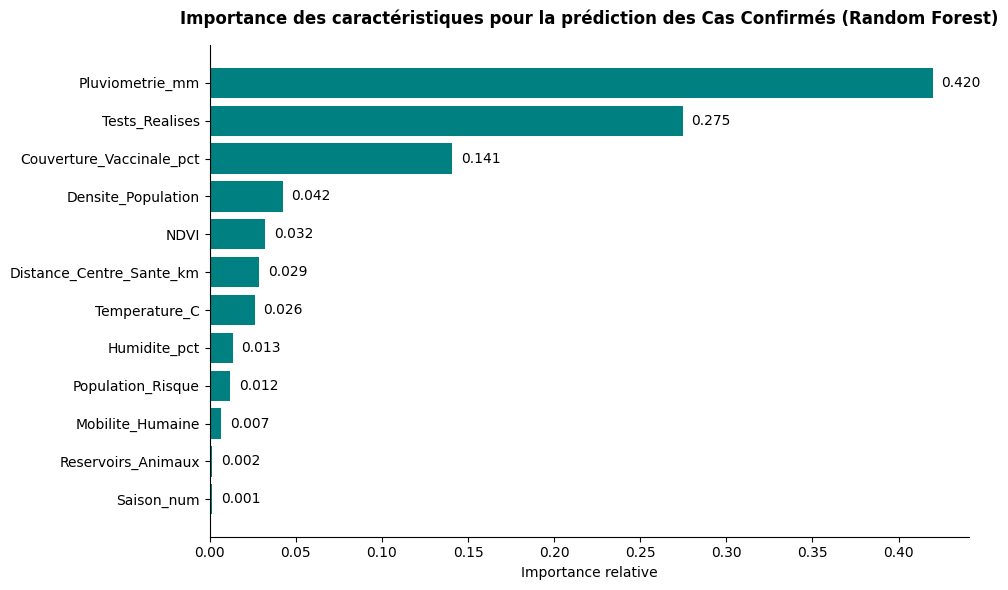

In [ ]:

features = x_train.columns

# 2. On trie les caractéristiques par ordre d'importance
importance = pd.DataFrame({
    'Feature': features,
    'Importance': models['Random Forest'].feature_importances_  # ou rf_optimized.feature_importances_
}).sort_values('Importance', ascending=True)

# 3. Création du graphique (taille adaptée pour un seul plot horizontal)
fig, ax = plt.subplots(figsize=(10, 6))

# On trace les barres horizontales
bars = ax.barh(importance['Feature'], importance['Importance'], color='teal')

# On ajoute les labels d'importance au bout de chaque barre
for bar in bars:
    width = bar.get_width()
    ax.text( width + 0.005, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center', ha='left', fontsize=10)

# Personnalisation des axes et du titre
ax.set_xlabel('Importance relative')
ax.set_title("Importance des caractéristiques pour la prédiction des Cas Confirmés (Random Forest)", 
             fontsize=12, fontweight='bold', pad=15)

# Suppression des bordures inutiles pour un look plus moderne (facultatif)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

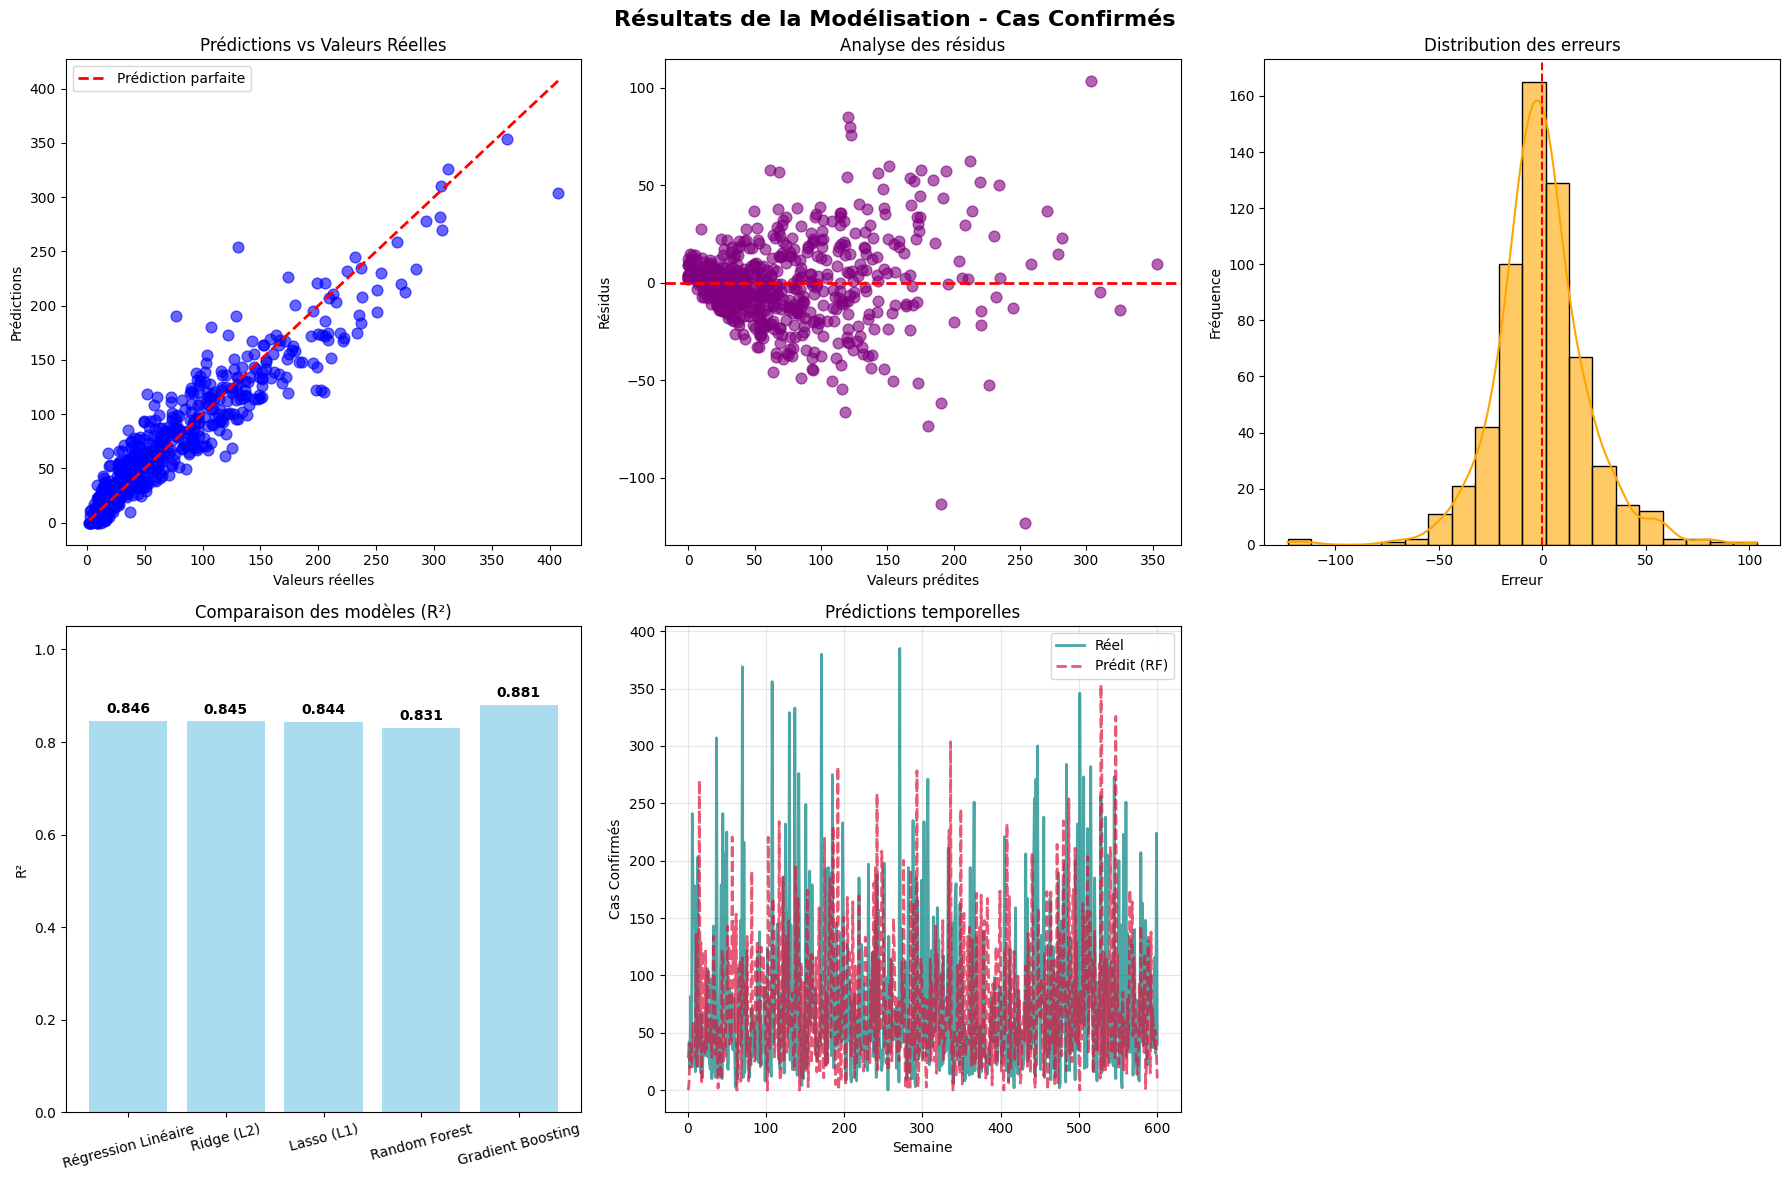

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Résultats de la Modélisation - Cas Confirmés', fontsize=16, fontweight='bold')

# On récupère les données de test et les prédictions du Random Forest (notre meilleur modèle)
y_reel = y_test
y_pred_rf = all_predictions['Gradient Boosting']
residuals = y_reel - y_pred_rf

# ==========================================================
# GRAPH les 1 : Prédictions vs Réel (En haut, à gauche)
# ==========================================================
ax2 = axes[0, 0]
ax2.scatter(y_reel, y_pred_rf, alpha=0.6, s=60, color='blue')
ax2.plot([y_reel.min(), y_reel.max()], [y_reel.min(), y_reel.max()], 
         'r--', lw=2, label='Prédiction parfaite')
ax2.set_xlabel('Valeurs réelles')
ax2.set_ylabel('Prédictions')
ax2.set_title('Prédictions vs Valeurs Réelles')
ax2.legend()

# ==========================================================
# GRAPH 2 : Analyse des Résidus (En haut, au milieu)
# ==========================================================
ax3 = axes[0, 1]
ax3.scatter(y_pred_rf, residuals, alpha=0.6, s=60, color='purple')
ax3.axhline(y=0, color='red', linestyle='--', lw=2)
ax3.set_xlabel('Valeurs prédites')
ax3.set_ylabel('Résidus')
ax3.set_title('Analyse des résidus')

# ==========================================================
# GRAPH 3 : Distribution des Erreurs (En haut, à droite)
# ==========================================================
ax4 = axes[0, 2]
sns.histplot(residuals, kde=True, bins=20, color='orange', alpha=0.6, ax=ax4)
ax4.axvline(0, color='red', linestyle='--')
ax4.set_xlabel('Erreur')
ax4.set_ylabel('Fréquence')
ax4.set_title('Distribution des erreurs')

# ==========================================================
# GRAPH 4 : Comparaison des Modèles (En bas, à gauche)
# ==========================================================
ax5 = axes[1, 0]
models_names = list(all_results.keys())
r2_scores = [all_results[name]['R²'] for name in models_names]
bars = ax5.bar(models_names, r2_scores, color='skyblue', alpha=0.7)
ax5.set_ylabel('R²')
ax5.set_title('Comparaison des modèles (R²)')
ax5.set_ylim(0, 1.05)  # Permet d'avoir de l'espace pour les étiquettes en haut des barres

# Correction pour éviter le warning de set_xticklabels sans ticks fixes
ax5.set_xticks(range(len(models_names)))
ax5.set_xticklabels(models_names, rotation=15)

for bar, score in zip(bars, r2_scores):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

# ==========================================================
# GRAPH 5 : Prédictions Temporelles (En bas, au milieu)
# ==========================================================
ax6 = axes[1, 1]
# On reconstruit un DataFrame de test indexé correctement
df_test = df.iloc[x_test.index].copy()
df_test['Prédictions'] = y_pred_rf

# On trie par semaine pour que la ligne temporelle ne s'entrecroise pas
df_test = df_test.sort_values('Semaine')

ax6.plot(df_test['Semaine'], df_test['Cas_Confirmes'], label='Réel', 
         linewidth=2, alpha=0.7, color='teal')
ax6.plot(df_test['Semaine'], df_test['Prédictions'], label='Prédit (RF)', 
         linewidth=2, alpha=0.7, linestyle='--', color='crimson')
ax6.set_xlabel('Semaine')
ax6.set_ylabel('Cas Confirmés')
ax6.set_title('Prédictions temporelles')
ax6.legend()
ax6.grid(True, alpha=0.3)

# ==========================================================
# NETTOYAGE : Suppression du 6ème subplot vide (En bas, à droite)
# ==========================================================
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

Afin de valider visuellement la robustesse de nos modélisations pour la prévision des cas de Mpox, une analyse graphique multicritère a été réalisée sur le jeu de test .

Ajustement global (Prédictions vs Réel) : L'alignement des points observés le long de la bissectrice de prédiction parfaite démontre une forte corrélation globale. Le modèle parvient à capter efficacement la dynamique générale de l'épidémie sur toute la plage de valeurs, bien qu'une légère sous-estimation linéaire apparaisse lors des vagues épidémiques extrêmes, notamment au-delà du seuil critique de 350 cas hebdomadaires.

Analyse des résidus et distribution des erreurs : Le graphique des résidus montre une dispersion globalement homogène de part d'autre de la ligne d'erreur nulle (y=0), sans structure géométrique aberrante ou hétéroscédasticité majeure. De plus, la distribution des erreurs suit une fonction de densité en cloche (quasi-normale) centrée sur zéro, ce qui confirme mathématiquement l'absence de biais systématique dans les prédictions du modèle.

Performance comparative (R²) : La comparaison objective des coefficients de détermination réaffirme la supériorité des approches non linéaires non paramétriques. Le Gradient Boosting s'impose avec un R² de 0.881, surpassant significativement le bloc des approches linéaires régularisées (R² = 0.84) ainsi que l'algorithme de Random Forest (R = 0.831).

Validation de la dynamique temporelle : La projection chronologique montre que la courbe des valeurs prédites épouse fidèlement les fluctuations, les phases de latence et les pics de la courbe réelle au fil des semaines. Cette haute réactivité temporelle valide scientifiquement l'intégration de ce modèle au sein d'un outil d'alerte précoce pour la gestion sanitaire en RDC.